# Task 3: Multimodal Machine Learning

## Objective

The goal of this project is to predict house prices using two different types of data:

- Tabular data (Bedrooms, Bathrooms, Area, ZipCode)
- House images (Front view)

A Convolutional Neural Network (CNN) is used to extract image features, which are then combined with the numerical house features. Finally, a regression model predicts the house price.

This demonstrates a multimodal machine learning approach because it uses multiple data sources simultaneously.

# Import Libraries

Import all required libraries for image processing,
tabular data preprocessing,
deep learning,
and evaluation.

In [14]:
import pandas as pd
import numpy as np
import os

from PIL import Image

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

## Load the Housing Dataset

The housing dataset contains numerical information for each house.

Features include:

- Bedrooms
- Bathrooms
- Area
- ZipCode
- Price (Target Variable)

These numerical features will later be combined with image features extracted using CNN.

In [15]:
df = pd.read_csv(r"C:\Users\wwwha\.ipynb_checkpoints\housing.csv")

df.head()

,Bedrooms,Bathrooms,Area,ZipCode,Price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


# Explore Dataset

Display:

- Shape
- Columns
- Missing values
- First five rows

In [16]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

df.head()

(535, 5)
<class 'pandas.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Bedrooms   535 non-null    int64  
 1   Bathrooms  535 non-null    float64
 2   Area       535 non-null    int64  
 3   ZipCode    535 non-null    int64  
 4   Price      535 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 21.0 KB
None
Bedrooms     0
Bathrooms    0
Area         0
ZipCode      0
Price        0
dtype: int64


,Bedrooms,Bathrooms,Area,ZipCode,Price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


## Create Image File Names

Each row in the dataset corresponds to one house.

The front-view image for each house is named:

1_frontal.jpg

2_frontal.jpg

...

535_frontal.jpg

A new column named **image** is created to match every row with its image.

In [17]:
df["image"] = [f"{i}_frontal.jpg" for i in range(1, len(df)+1)]

df.head()

,Bedrooms,Bathrooms,Area,ZipCode,Price,image
0,4,4.0,4053,85255,869500,1_frontal.jpg
1,4,3.0,3343,36372,865200,2_frontal.jpg
2,3,4.0,3923,85266,889000,3_frontal.jpg
3,5,5.0,4022,85262,910000,4_frontal.jpg
4,3,4.0,4116,85266,971226,5_frontal.jpg


## Load the CNN Model

Instead of training a CNN from scratch, we use a pre-trained MobileNetV2 model.

The classifier layer is removed so that the model only extracts image features.

In [18]:
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

C:\Users\wwwha\AppData\Local\Temp\ipykernel_36308\2177867251.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step


## Extract Image Features

Every house image is:

- Loaded
- Resized to 224×224
- Converted to an array
- Preprocessed
- Passed through MobileNetV2

The output is a feature vector describing important visual characteristics of the house.

In [19]:
image_folder = r"C:\Users\wwwha\.ipynb_checkpoints\Houses_Dataset"

image_features = []

for file in df["image"]:

    img_path = os.path.join(image_folder, file)

    img = image.load_img(img_path, target_size=(224,224))

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    feature = cnn.predict(img_array, verbose=0)

    image_features.append(feature.flatten())

image_features = np.array(image_features)

print(image_features.shape)

(535, 1280)


## Prepare Tabular Features

The numerical features are selected from the dataset.

The target variable is the house price.

In [20]:
X_tabular = df[
    [
        "Bedrooms",
        "Bathrooms",
        "Area",
        "ZipCode"
    ]
]

y = df["Price"]

## Scale Numerical Features

Feature scaling helps numerical variables have similar ranges before combining them with image features.

In [21]:
scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)

## Combine Image and Tabular Features

The CNN image features are concatenated with the scaled numerical features to create one combined feature vector for every house.

In [22]:
X = np.concatenate(
    [X_tabular, image_features],
    axis=1
)

print(X.shape)

(535, 1284)


## Split the Dataset

The data is divided into training and testing sets.

80% is used for training and 20% is used for evaluation.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train the Regression Model

A Random Forest Regressor is trained using the combined multimodal features.

In [24]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Make Predictions

The trained model predicts house prices on the test dataset.

In [25]:
predictions = model.predict(X_test)

## Evaluate the Model

Two regression metrics are calculated:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

Smaller values indicate better prediction performance.

In [26]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE :", mae)

print("RMSE:", rmse)

MAE : 221984.75775700933
RMSE: 294837.48503097665


## Visualize Predictions

The scatter plot compares actual house prices with predicted house prices.

Points closer to the diagonal indicate better model performance.

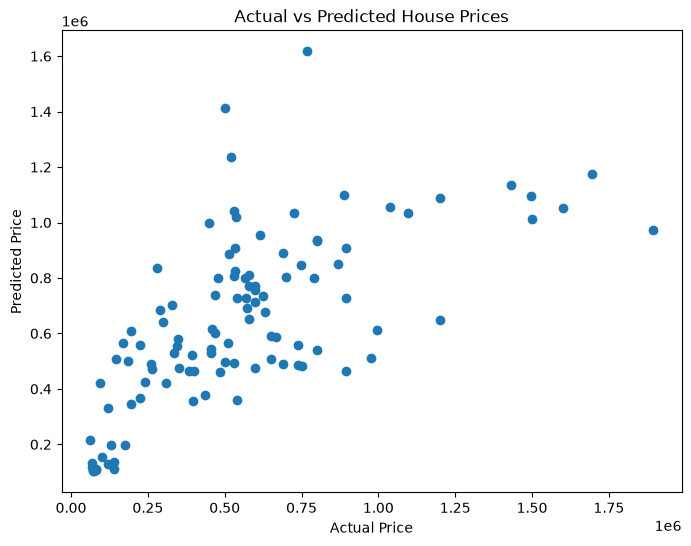

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

# Conclusion

In this project, a multimodal machine learning model was developed to predict housing prices using both structured tabular data and house images.

A pre-trained MobileNetV2 CNN extracted visual features from house images, while numerical features such as bedrooms, bathrooms, area, and ZIP code were standardized and combined with the image features. A Random Forest Regressor was then trained on the fused feature set.

The model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), demonstrating how combining multiple data modalities can improve predictive performance compared to using only one type of data.

This project provided practical experience with multimodal learning, CNN-based feature extraction, feature fusion, regression modeling, and model evaluation, making it suitable for real-world AI and machine learning applications.